In [14]:
import os
from collections import defaultdict

import gensim.downloader as api
from gensim.models import Word2Vec
import networkx as nx 
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import re

## Evaluation

In [15]:
# Read in a graph (just used to get word lists for analogies)
graph_weighted = nx.read_gexf('data/graph_weighted_with_probs.gexf')
# graph_unweighted = nx.read_gexf('data/pos_tagged_graph_original.gexf')

In [16]:
pq_to_display = {
    'weighted_graph': [(1, 0.25), (1,0.5), (1,1), (1,2)],
    'unweighted_graph': [(1, 0.25), (1,0.5), (1,1), (1,2)]
}

windows_to_display = {
    'weighted_graph': [3,5,10],
    'unweighted_graph': [3,5,10]
}

INCLUDE_GOOGLE = True      # Mark True if you want to run Analogy Tests and 
                            # Analysis on Google's PreTrained Embeddings

In [17]:
models = {}         # map of keys to actual models

# lists of model keys
graph_models = []
unweighted_graph_models = []
weighted_graph_models = []
google_models = []
all_models = []

# get google pretrained embeddings
google_model= api.load('word2vec-google-news-300')      # Still needed for some parts, 
                                                        # even if INCLUDE_GOOGLE is False.
                                                        # Used to make tests with a consistent vocab

if INCLUDE_GOOGLE:
    models['google_word2vec'] = google_model
    google_models.append('google_word2vec')

# load unweighted graph embeddings
for (p,q) in pq_to_display['unweighted_graph']:
    for k in windows_to_display['unweighted_graph']:
        graph_key = f'unweighted_p{p}_q{q}_window_{k}'
        models[graph_key] = Word2Vec.load(f"data/unweighted_graph_embeddings_p{p}_q{q}_window{k}.model").wv
        graph_models.append(graph_key)
        unweighted_graph_models.append(graph_key)

# load weighted graph embeddings
for (p,q) in pq_to_display['weighted_graph']:
    for k in windows_to_display['weighted_graph']:
        graph_key = f'weighted_p{p}_q{q}_window_{k}'
        models[graph_key] = Word2Vec.load(f"data/weighted_graph_embeddings_p{p}_q{q}_window{k}.model").wv
        graph_models.append(graph_key)
        weighted_graph_models.append(graph_key)

all_models = google_models + graph_models

In [18]:
# Create an index mapping words to nodes that match
word_node_index = defaultdict(list)
for node, data in graph_weighted.nodes(data=True):
    if data['type'] != 'meta':
        word = data['value']
        word_node_index[word].append((node, data))

In [19]:
def get_nodes(word, *pos_info):
    nodes = [n for n, _ in word_node_index[word.lower()]]
    if len(pos_info) == 0:
        return nodes

    valid_nodes = []
    for node in nodes:
        match = True
        for item in pos_info:
            if f"'{item}'" not in node:
                match=False
                break
        if match:
            valid_nodes.append(node)

    return valid_nodes

#### Analogy Tests

### Prep

In [20]:
# read in analogies
analogies_folder = 'analogies'
analogies_master = {}
for analogy_file in os.listdir(analogies_folder):
    category = analogy_file[:-4]
    analogies_master[category] = pd.read_table(os.path.join(analogies_folder, analogy_file), sep=" ", header=None)
    analogies_master[category].columns = ['w1', 'r1', 'w2', 'r2']
    

In [21]:
# get and save a list of all nodes for words in the analogies
words_not_in_graph = []
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        for word in row:
            if word not in word_node_index:
                if len(get_nodes(word)) == 0:
                    words_not_in_graph.append(word)

print(f'Words Not in Graph: {words_not_in_graph}')

superlative: 100%|██████████| 1122/1122 [00:00<00:00, 70133.22it/s]

Words Not in Graph: ['Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Belmopan', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Ashgabat', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmopan', 'Belmop

In [22]:
# clean analogies
for category, tests in analogies_master.items():
    analogies_master[category] = tests[~tests.isin(words_not_in_graph).any(axis=1)]

### Tests

In [23]:
google_words = set([word.lower() for word in google_model.index_to_key])

In [24]:
# create lists of analogies, but in a format of the embeddings models can take. 
# for graphical models, this generates analogies using nodes.
# for google, this generates analogies using words themselves.
# filters out analogies that have words that are either not in the graph or not in google's list
analogy_nodes = defaultdict(list)
analogy_google = defaultdict(list)
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        w1, r1, w2, r2 = row
        w1_nodes = get_nodes(w1)
        r1_nodes = get_nodes(r1)
        w2_nodes = get_nodes(w2)
        r2_nodes = get_nodes(r2)

        nodes1_3 = set()
        for node1 in w1_nodes:     # for each node that is the first word in the analogy
            try:
                node3 = [node for node in w2_nodes if eval(node)[1:] == eval(node1)[1:]][0]    # find the node for the third word that has the same pos
                nodes1_3.add((node1, node3))
            except IndexError:
                continue
            
            
        nodes2_4 = set() 
        for node2 in r1_nodes:    # then for each word that is the second word in the analogy
            try:
                node4 = [node for node in r2_nodes if eval(node)[1:] == eval(node2)[1:]][0]    # find the node for the third word that has the same pos
                nodes2_4.add((node2, node4))
            except IndexError:
                continue

        for node1, node3 in nodes1_3:
            for node2, node4 in nodes2_4:
                if (eval(node1)[0] in google_words) and (eval(node2)[0] in google_words) \
                        and (eval(node3)[0] in google_words) and (eval(node4)[0] in google_words):
                    
                    analogy_nodes[category].append((node1, node2, node3, node4))
                    analogy_google[category].append((w1, r1, w2, r2))
                    
                    
            

superlative: 100%|██████████| 1056/1056 [00:00<00:00, 2470.26it/s]


In [25]:

# function to calculate accuracies using analogies for the different models
def calculate_analogy_accuracy(analogies_list, model_keys, accuracies):
    for category, analogies in analogies_list.items():
        for analogy in tqdm(analogies, f'calculating for {category}...'):
            w1, r1, w2, r2 = analogy
            
            for model_key in model_keys:
                model = models[model_key]
                
                try:
                    r2_hat = model[w2] + (model[r1] - model[w1])
                except KeyError:
                    print(model_key, w1, r1, w2, r2)
                    continue
                most_similar = [item[0] for item in model.similar_by_vector(r2_hat, topn=10)]
    
                if r2 in most_similar[:1]:
                    accuracies[model_key][category]['top1'] += 1
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:5]:
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:10]:
                    accuracies[model_key][category]['top10'] += 1


In [26]:
# initialize
accuracies = {}
for model in models:
    accuracies[model] = {}
    for category in analogy_nodes:
        accuracies[model][category] = {}
        accuracies[model][category]['top1'] = 0
        accuracies[model][category]['top5'] = 0
        accuracies[model][category]['top10'] = 0

# calculate accuracies for the four different models
print('Graph models:')
calculate_analogy_accuracy(analogy_nodes, graph_models, accuracies)

if INCLUDE_GOOGLE:
    print('Google model:')
    calculate_analogy_accuracy(analogy_google, google_models, accuracies)

# normalize accuracies
for model in models:
    for category in analogy_nodes:
        num = len(analogy_nodes[category])
        for count_key in accuracies[model][category]:
            accuracies[model][category][count_key] /= num     

Graph models:


calculating for superlative...: 100%|██████████| 5066/5066 [10:47<00:00,  7.82it/s]


Google model:


calculating for superlative...: 100%|██████████| 5066/5066 [10:15<00:00,  8.23it/s]


### Display Results

In [27]:
def display_results(model_list: list[str], p='', q=''):
    _model_list = [mk for mk in model_list if f'p{p}_q{q}_' in mk]
    for model_key in _model_list:
        print(model_key)
        display(pd.DataFrame(accuracies[model_key]))

#### Display Unweighted Graph Embedding Results

##### p=1, q=0.25

In [28]:
display_results(unweighted_graph_models, p=1,q=0.25)

unweighted_p1_q0.25_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000337,0.000498,0.039334,0.008578,0.018343,0.000000,0.008869,0.007971,0.003019,0.000395
top5,0.115723,0.021445,0.028995,0.168905,0.261725,0.213848,0.332758,0.006509,0.382550,0.499275,0.196578,0.168180
top10,0.179245,0.048766,0.073163,0.198134,0.372920,0.369485,0.427492,0.017751,0.521812,0.600181,0.291345,0.190683


unweighted_p1_q0.25_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000441,0.000000,0.000249,0.019667,0.002451,0.016185,0.000000,0.004554,0.005616,0.000839,0.000197
top5,0.120755,0.027615,0.040796,0.152985,0.273828,0.174020,0.372249,0.005917,0.336529,0.500000,0.215699,0.145874
top10,0.179245,0.057286,0.090357,0.188433,0.403177,0.343137,0.462451,0.015385,0.483941,0.619203,0.294700,0.178445


unweighted_p1_q0.25_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000337,0.000498,0.015129,0.000000,0.017048,0.000000,0.002637,0.002536,0.000168,0.000790
top5,0.123270,0.035987,0.065745,0.121642,0.257943,0.156863,0.357790,0.002959,0.222915,0.426630,0.222912,0.114291
top10,0.190566,0.073002,0.131490,0.163930,0.368381,0.308824,0.461157,0.008876,0.354506,0.553261,0.297887,0.152981


##### p=1, q=0.5

In [29]:
display_results(unweighted_graph_models, p=1,q=0.5)

unweighted_p1_q0.5_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000881,0.000000,0.000746,0.037065,0.009191,0.018558,0.000000,0.008389,0.007971,0.003187,0.000790
top5,0.128931,0.027174,0.034053,0.168781,0.292738,0.236520,0.344411,0.004734,0.385666,0.501449,0.195740,0.171536
top10,0.191195,0.057579,0.083614,0.196517,0.406959,0.362132,0.439361,0.017160,0.524209,0.598370,0.292016,0.188512


unweighted_p1_q0.5_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000147,0.000337,0.000249,0.024962,0.006127,0.016185,0.000000,0.003116,0.003804,0.001510,0.000197
top5,0.124528,0.029671,0.046190,0.150995,0.285174,0.198529,0.356711,0.005917,0.321908,0.515761,0.224589,0.151007
top10,0.184906,0.063602,0.100135,0.187189,0.409228,0.335784,0.447130,0.017751,0.461170,0.624275,0.303925,0.181800


unweighted_p1_q0.5_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000337,0.000871,0.012103,0.000613,0.013164,0.000000,0.003116,0.001268,0.001006,0.000395
top5,0.140881,0.041569,0.073500,0.125249,0.236762,0.153186,0.351316,0.004142,0.233701,0.434601,0.211338,0.115673
top10,0.198742,0.081228,0.148011,0.168532,0.354009,0.284314,0.450798,0.009467,0.361457,0.561232,0.289836,0.164627


##### p=1, q=1

In [30]:
display_results(unweighted_graph_models, p=1,q=1)

unweighted_p1_q1_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000588,0.001349,0.000622,0.037821,0.012868,0.021364,0.000000,0.010547,0.009239,0.004361,0.000790
top5,0.138994,0.027615,0.035064,0.169527,0.319970,0.272672,0.344195,0.011243,0.379434,0.495290,0.203958,0.163048
top10,0.192453,0.060370,0.088672,0.198134,0.444024,0.395221,0.431593,0.029586,0.518217,0.585507,0.296880,0.191670


unweighted_p1_q1_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000000,0.000373,0.015129,0.007966,0.012948,0.000000,0.004314,0.006703,0.001174,0.000197
top5,0.129560,0.025999,0.050236,0.157960,0.309380,0.235907,0.381959,0.007692,0.351151,0.510326,0.223415,0.147454
top10,0.198742,0.056110,0.107215,0.189428,0.428896,0.375000,0.472162,0.017160,0.484660,0.614312,0.306273,0.174891


unweighted_p1_q1_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000629,0.000294,0.000000,0.000622,0.008321,0.000000,0.012516,0.000000,0.002397,0.004348,0.000671,0.000395
top5,0.138994,0.038190,0.055630,0.127985,0.286687,0.185049,0.347000,0.005917,0.249760,0.435145,0.220731,0.126925
top10,0.201258,0.076087,0.120027,0.171020,0.403933,0.330270,0.439145,0.014793,0.375360,0.564855,0.300067,0.166009


##### p=1, q=2

In [31]:
display_results(unweighted_graph_models, p=1,q=2)

unweighted_p1_q2_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000337,0.000249,0.054463,0.010417,0.022443,0.000000,0.013183,0.007790,0.003858,0.000592
top5,0.122642,0.029524,0.052933,0.174129,0.301059,0.240196,0.335563,0.008284,0.404362,0.497826,0.203120,0.164232
top10,0.189937,0.060076,0.111935,0.199751,0.403933,0.383578,0.418645,0.021302,0.534995,0.593297,0.298390,0.188709


unweighted_p1_q2_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000147,0.000000,0.000498,0.031770,0.006127,0.013379,0.000000,0.007910,0.006522,0.001174,0.000790
top5,0.130189,0.029230,0.050573,0.154104,0.316188,0.245098,0.369012,0.008876,0.337967,0.496558,0.213519,0.153968
top10,0.194340,0.060958,0.112272,0.184826,0.435703,0.405637,0.450367,0.021893,0.471716,0.607609,0.301577,0.183577


unweighted_p1_q2_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000000,0.000498,0.015129,0.001225,0.013811,0.000000,0.001918,0.002717,0.000168,0.000592
top5,0.141509,0.038631,0.064734,0.135572,0.291982,0.213848,0.341390,0.006509,0.239693,0.430797,0.213519,0.122977
top10,0.203145,0.073590,0.135199,0.176119,0.401664,0.366422,0.435045,0.017751,0.373921,0.562138,0.295538,0.162653


#### Display Weighted Graph Embedding Results

##### p=1, q=0.25

In [32]:
display_results(weighted_graph_models, p=1, q=0.25)

weighted_p1_q0.25_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000734,0.000000,0.000000,0.001513,0.006127,0.003884,0.000000,0.015340,0.009783,0.006374,0.000592
top5,0.136478,0.025852,0.019218,0.145647,0.037065,0.159314,0.276867,0.003550,0.252157,0.375362,0.119758,0.148243
top10,0.189308,0.051410,0.045516,0.177861,0.107413,0.223652,0.370091,0.010059,0.365532,0.473913,0.191043,0.183577


weighted_p1_q0.25_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000147,0.000337,0.000249,0.000756,0.002451,0.003669,0.000000,0.007910,0.005254,0.004025,0.000197
top5,0.149686,0.030259,0.020229,0.134701,0.037065,0.140931,0.249676,0.003550,0.216203,0.373551,0.129319,0.138176
top10,0.205660,0.062133,0.039110,0.176119,0.080938,0.217525,0.350237,0.012426,0.321668,0.491667,0.197417,0.180024


weighted_p1_q0.25_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.002516,0.000000,0.000337,0.000746,0.000000,0.000613,0.005395,0.000000,0.003595,0.002899,0.001342,0.000395
top5,0.146541,0.035400,0.030681,0.131219,0.030257,0.105392,0.248166,0.007101,0.169223,0.361051,0.124958,0.124556
top10,0.203145,0.076675,0.057991,0.176617,0.077912,0.170343,0.341606,0.021302,0.277325,0.511957,0.195069,0.171931


##### p=1, q=0.5

In [33]:
display_results(weighted_graph_models, p=1, q=0.5)

weighted_p1_q0.5_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.001028,0.001011,0.000000,0.000000,0.005515,0.003453,0.000000,0.015820,0.011413,0.004193,0.000987
top5,0.150943,0.027615,0.018206,0.143284,0.058245,0.168505,0.282909,0.004142,0.241611,0.395833,0.114559,0.154757
top10,0.198113,0.057579,0.036750,0.179602,0.118003,0.233456,0.360380,0.011243,0.338207,0.481341,0.181315,0.188117


weighted_p1_q0.5_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000373,0.000756,0.007966,0.004100,0.000000,0.010307,0.008333,0.001677,0.000395
top5,0.174214,0.026733,0.021241,0.143035,0.046142,0.156863,0.268451,0.005325,0.223873,0.380797,0.120262,0.140742
top10,0.223270,0.061105,0.040121,0.181343,0.090015,0.231005,0.340311,0.014201,0.326942,0.503623,0.179638,0.185748


weighted_p1_q0.5_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000629,0.000147,0.000000,0.000622,0.000000,0.002451,0.003884,0.000000,0.004075,0.002536,0.002013,0.000000
top5,0.149057,0.033049,0.023264,0.122139,0.044629,0.113971,0.253776,0.007692,0.171381,0.367391,0.131667,0.127912
top10,0.195597,0.074177,0.046864,0.180348,0.114977,0.172794,0.348079,0.021893,0.276606,0.512681,0.200939,0.180813


##### p=1, q=1

In [34]:
display_results(weighted_graph_models, p=1, q=1)

weighted_p1_q1_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000000,0.000373,0.000000,0.012868,0.003237,0.000000,0.017258,0.010326,0.006709,0.000592
top5,0.164151,0.022914,0.024612,0.144154,0.072617,0.160539,0.282046,0.002367,0.231304,0.382065,0.130325,0.155744
top10,0.211950,0.050969,0.046864,0.184950,0.128593,0.228554,0.354985,0.007692,0.333653,0.482246,0.195907,0.188314


weighted_p1_q1_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000373,0.001513,0.004902,0.004100,0.000000,0.009108,0.005978,0.004529,0.000395
top5,0.159748,0.025999,0.027984,0.144527,0.071861,0.139706,0.272551,0.001183,0.188399,0.377174,0.125294,0.143308
top10,0.203774,0.058901,0.053608,0.186940,0.126324,0.207108,0.351532,0.007692,0.296500,0.503804,0.194733,0.186735


weighted_p1_q1_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000629,0.000000,0.000000,0.000373,0.000000,0.000613,0.003237,0.000000,0.003595,0.001812,0.000839,0.000000
top5,0.150943,0.030993,0.036413,0.136816,0.052950,0.101103,0.268019,0.004142,0.163471,0.359783,0.144582,0.126925
top10,0.206289,0.065071,0.068780,0.183085,0.107413,0.166667,0.345274,0.015976,0.264621,0.494203,0.212680,0.176471


##### p=1, q=2

In [35]:
display_results(weighted_graph_models, p=1, q=2)

weighted_p1_q2_window_3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000881,0.000337,0.000000,0.001513,0.003064,0.005395,0.000000,0.017977,0.011051,0.004529,0.000592
top5,0.160377,0.024530,0.025624,0.149751,0.082451,0.147672,0.290893,0.004734,0.248322,0.380072,0.118081,0.149625
top10,0.211321,0.052145,0.040459,0.184204,0.141452,0.229779,0.351101,0.013018,0.349233,0.484420,0.179973,0.186538


weighted_p1_q2_window_5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000629,0.000147,0.000000,0.000000,0.000000,0.003676,0.001726,0.000000,0.006472,0.006522,0.004361,0.000197
top5,0.155975,0.023502,0.017869,0.148383,0.051437,0.125000,0.285714,0.005917,0.198706,0.364130,0.126468,0.135413
top10,0.217610,0.051998,0.036076,0.186940,0.104387,0.180147,0.350669,0.020118,0.295781,0.486051,0.194566,0.186340


weighted_p1_q2_window_10


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.001887,0.000000,0.000000,0.000746,0.000000,0.000613,0.003669,0.000000,0.002637,0.002899,0.002013,0.000000
top5,0.158491,0.025705,0.018881,0.137189,0.046899,0.118260,0.280104,0.011243,0.160834,0.337862,0.129990,0.117450
top10,0.213836,0.062867,0.038436,0.185075,0.105144,0.175858,0.350453,0.022485,0.266779,0.472283,0.201610,0.170549


#### Display Google Embedding Results

In [36]:
if INCLUDE_GOOGLE:
    display_results(google_models)

#### Display Custom List of Results

In [37]:
custom_list = []        # fill in here with model_keys, e.g. weighted_graph_p1_q1_window3
display_results(custom_list)

### Bias Check

#### Define Terms to Check
**NOTE:** This is a rough list generated from ChatGPT and may not reflect all opinions. 

In [38]:
# Occupations

men_occupations = [
    'Engineer',
    'Construction',
    'Firefighter',
    'Mechanic',
    'Plumber',
    'Electrician',
    'Pilot',
    'Information_Technology',
    'Soldier',
    'CEO',
    'Computer_Programmer'
]

women_occupations = [
    'Nurse',
    'Teacher',
    'Secretary',
    'Receptionist',
    'Nanny',
    'Librarian',
    'Waitress',
    'Hairdresser',
    'Flight_attendant',
    'Dancer',
    'Homemaker'
]

In [39]:
# Sports

sports_men = [
    'Football',
    'Soccer',
    'Baseball',
    'Basketball',
    'Boxing',
    'Rugby',
    'Wrestling',
    'Ice_Hockey',
    'Golf',
]

sports_women = [
    'Gymnastics',
    'Figure_Skating',
    'Swimming',
    'Ballet',
    'Cheerleading',
    'Equestrian',
    'Netball',
    'Volleyball'
]

In [40]:
# Instruments

instruments_men = [
    'Electric_Guitar',
    'Drums',
    'Trumpet',
    'Saxophone',
    'Bass_Guitar',
    'Trombone',
    'Violin',
    'Bass',
    'Cello',
]

instruments_women = [
    'Flute',
    'Harp',
    'Clarinet',
    'Viola',
    'Piano',
    'Oboe',
    'Harp',
    'Keyboard',
]

In [41]:
mens = men_occupations + sports_men + instruments_men
womens = women_occupations + sports_women + instruments_women

#### Make Plots

In [102]:
def calculate_plot_points(model_key):
    model = models[model_key]
    if model_key != 'google_word2vec':  
        man_key = "('man', 'n', 'singular', 'common')"
        woman_key = "('woman', 'n', 'singular', 'common')"
    else:
        man_key = 'man'
        woman_key = 'woman'
        
    man_emb = model[man_key]
    woman_emb = model[woman_key]
    magnitude_man = np.linalg.norm(man_emb)
    magnitude_woman = np.linalg.norm(woman_emb)

    mens_x = []
    mens_y = []

    womens_x = []
    womens_y = []
    
    for item in mens + womens:
        if model_key != 'google_word2vec':  
            nodes = [node for node in get_nodes(item) if 'UNK_POS' not in node]
        else:
            nodes = [item]

        for node in nodes:
            item_emb = model[node]
            magnitude_item = np.linalg.norm(item_emb)
            
            similarity_man = np.dot(item_emb, man_emb) / (magnitude_man * magnitude_item)
            similarity_woman = np.dot(item_emb, woman_emb) / (magnitude_woman * magnitude_item)
            #ax.annotate(node, (similarity_man, similarity_woman), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)
            if item in mens:
                mens_x.append(similarity_man)
                mens_y.append(similarity_woman)
            else:
                womens_x.append(similarity_man)
                womens_y.append(similarity_woman)
                
    return mens_x, mens_y, womens_x, womens_y
    

In [103]:
def make_plots_grid(model_list: list[str], grid_width=2, file_name=None):
    num_plots = len(model_list)
    grid_height = num_plots // grid_width + (0 if num_plots % grid_width == 0 else 1)
    fig, axs = plt.subplots(grid_height, grid_width, squeeze=False, figsize=(18, 18))
    i, j = (0, 0)

    for model_key in tqdm(model_list):
        mens_x, mens_y, womens_x, womens_y = calculate_plot_points(model_key)

        ax = axs[i,j]
        ax.scatter(mens_x, mens_y, color='blue', label='Labeled Men\'s')
        ax.scatter(womens_x, womens_y, color='orange', label='Labeled Women\'s')
        ax.legend()
        ax.set_xlabel('Similarity to Man')
        ax.set_ylabel('Similarity to Woman')
        ax.set_title(model_key)
        ax.set_aspect('equal', adjustable='box')
        j = (j + 1) % grid_width
        if j == 0:
            i += 1


    while (j % grid_width) != 0:
        subplot = axs[i,j]
        subplot.set_visible(False)
        j += 1
    
    if file_name:
        plt.savefig(f'../figures/{file_name}.png')
        print(f'plots saved to ../figures/{file_name}.png')

    plt.show()

In [104]:
def display_and_save_bias_plots(model_list: list[str], label='', p='', q=''):
    if p or q:
        _model_list = [mk for mk in model_list if f'p{p}_q{q}_' in mk]
    else:
        _model_list = model_list
    batches = []
    k = 0
    while k < len(_model_list):
        j = k
        k += 4
        batches.append(_model_list[j:k])

    for i, batch in enumerate(batches):
        print(batch)
        pq_label = f'_p{p}' if p != '' else ''
        pq_label += f'_q{q}' if q != '' else ''
        file_name=f"bias_plots_{label}_{pq_label}{f'_batch{i}' if len(batches) > 1 else ''}"
        grid_width = 2 if len(_model_list) > 1 else 1
        make_plots_grid(model_list=batch, grid_width=grid_width, 
                        file_name=file_name)

##### Google Embeddings

['google_word2vec']


100%|██████████| 1/1 [00:00<00:00, 276.76it/s]

plots saved to ../figures/bias_plots_google_.png


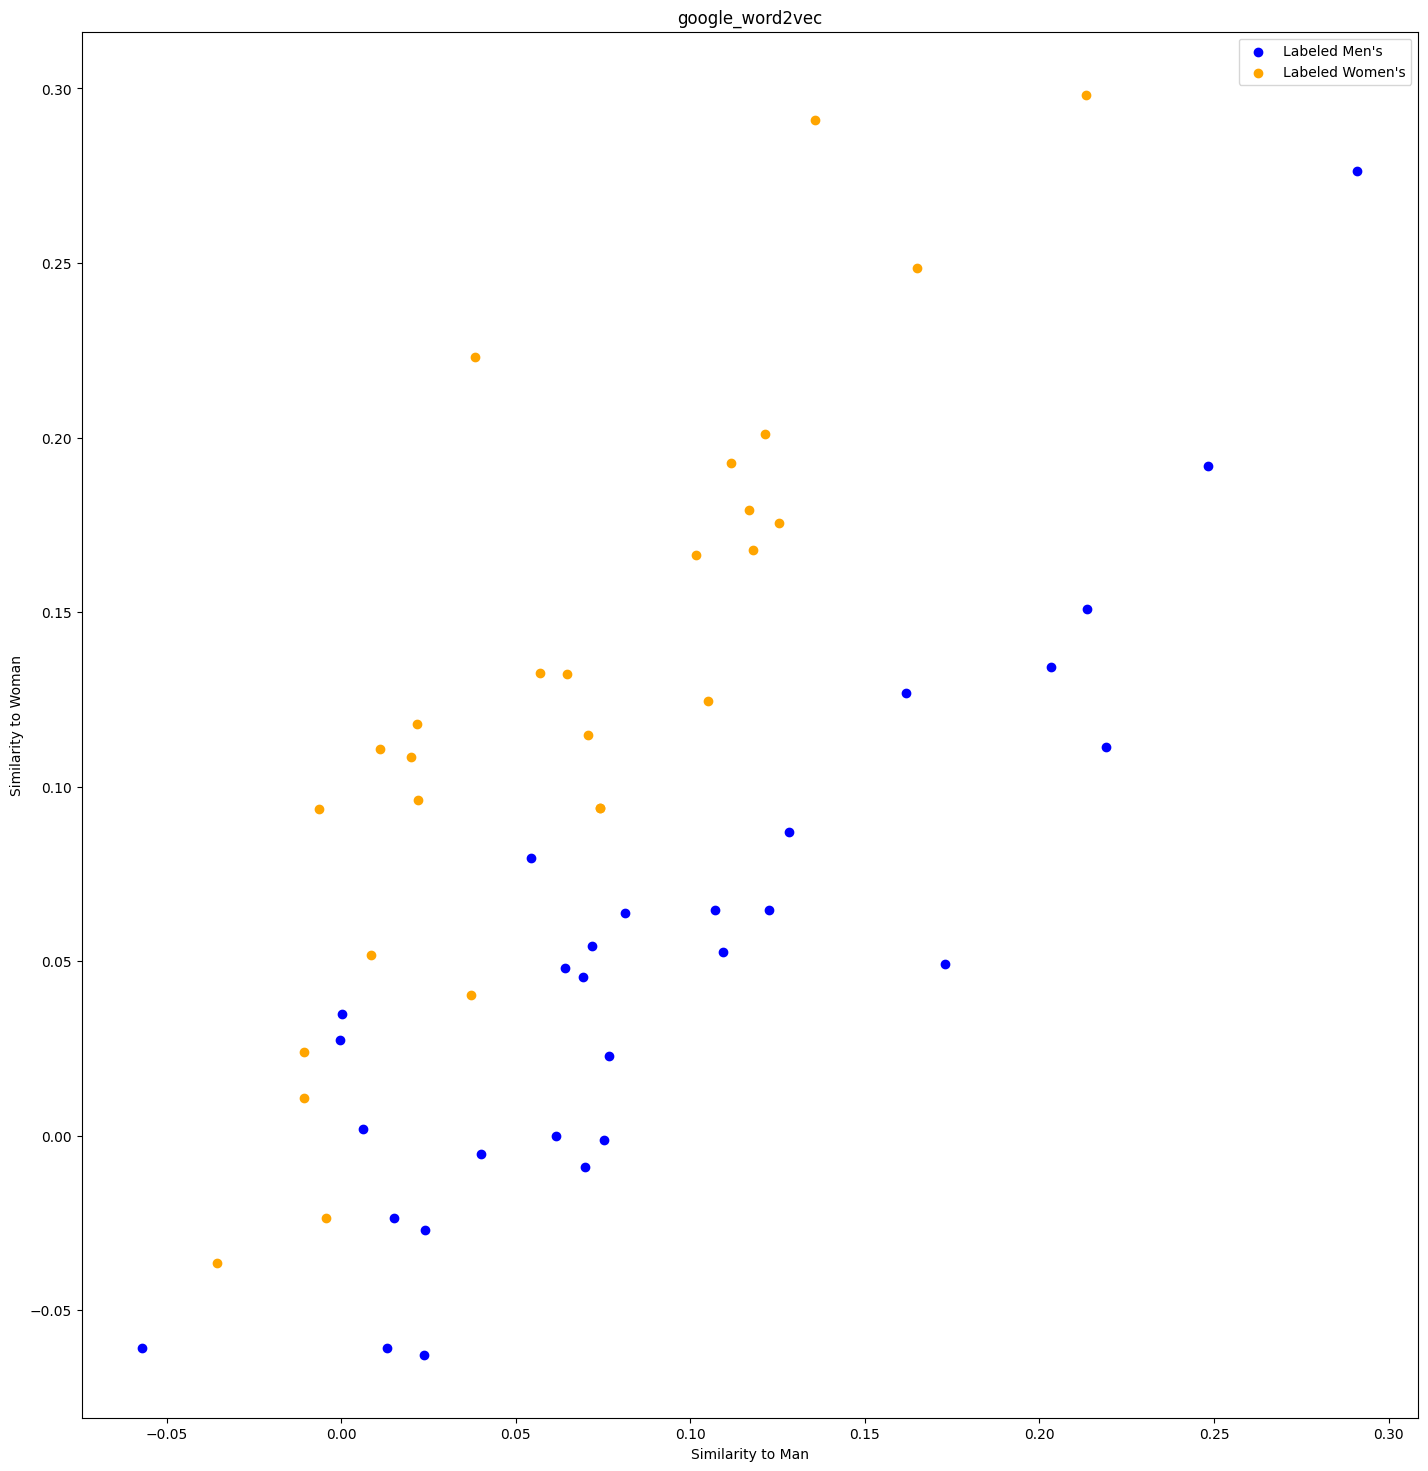

In [105]:
if INCLUDE_GOOGLE:
    display_and_save_bias_plots(model_list=google_models, label='google')

##### Unweighted Graph Embeddings

['unweighted_p1_q0.25_window_3', 'unweighted_p1_q0.25_window_5', 'unweighted_p1_q0.25_window_10']


100%|██████████| 3/3 [00:00<00:00, 250.01it/s]

plots saved to ../figures/bias_plots_unweighted__p1_q0.25.png


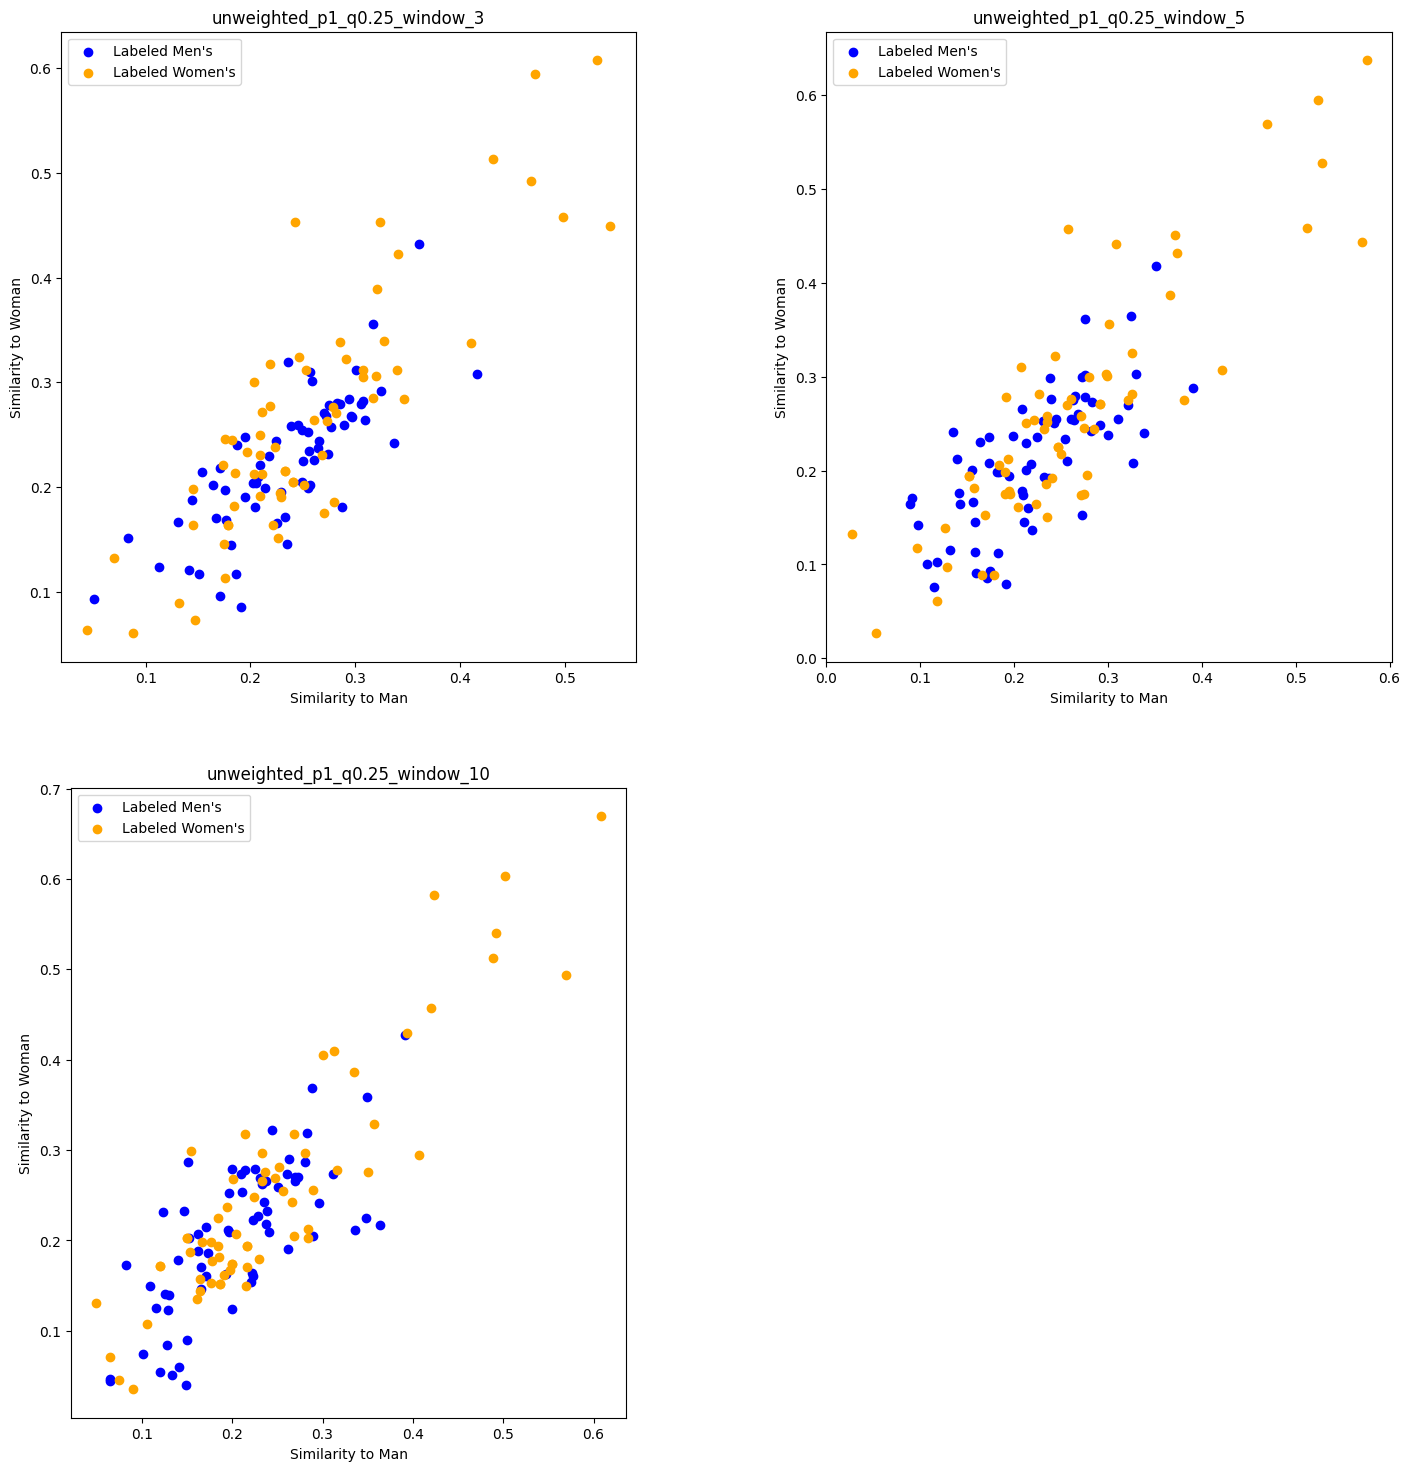

In [106]:
display_and_save_bias_plots(model_list=unweighted_graph_models, label='unweighted', p=1, q=0.25)

['unweighted_p1_q0.5_window_3', 'unweighted_p1_q0.5_window_5', 'unweighted_p1_q0.5_window_10']


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 252.34it/s]

plots saved to ../figures/bias_plots_unweighted__p1_q0.5.png


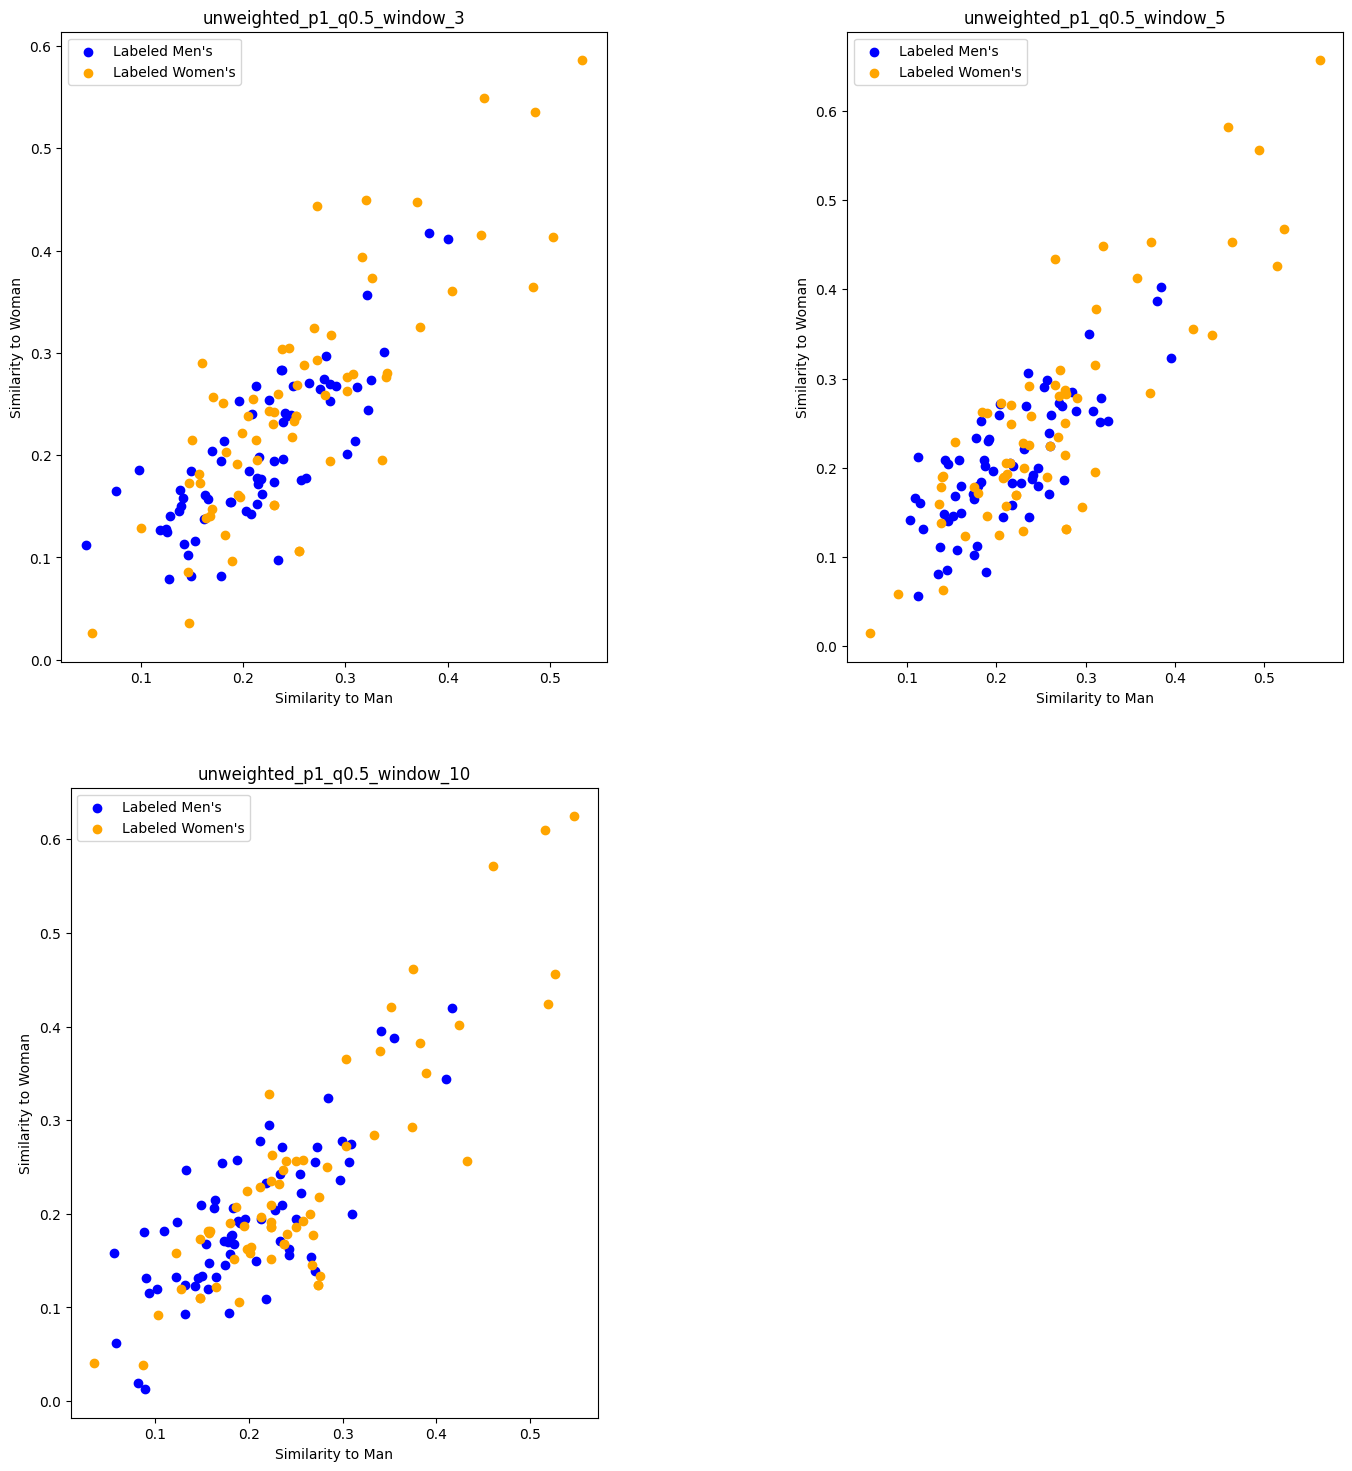

In [107]:
display_and_save_bias_plots(model_list=unweighted_graph_models, label='unweighted', p=1, q=0.5)

['unweighted_p1_q1_window_3', 'unweighted_p1_q1_window_5', 'unweighted_p1_q1_window_10']


100%|██████████| 3/3 [00:00<00:00, 272.74it/s]

plots saved to ../figures/bias_plots_unweighted__p1_q1.png


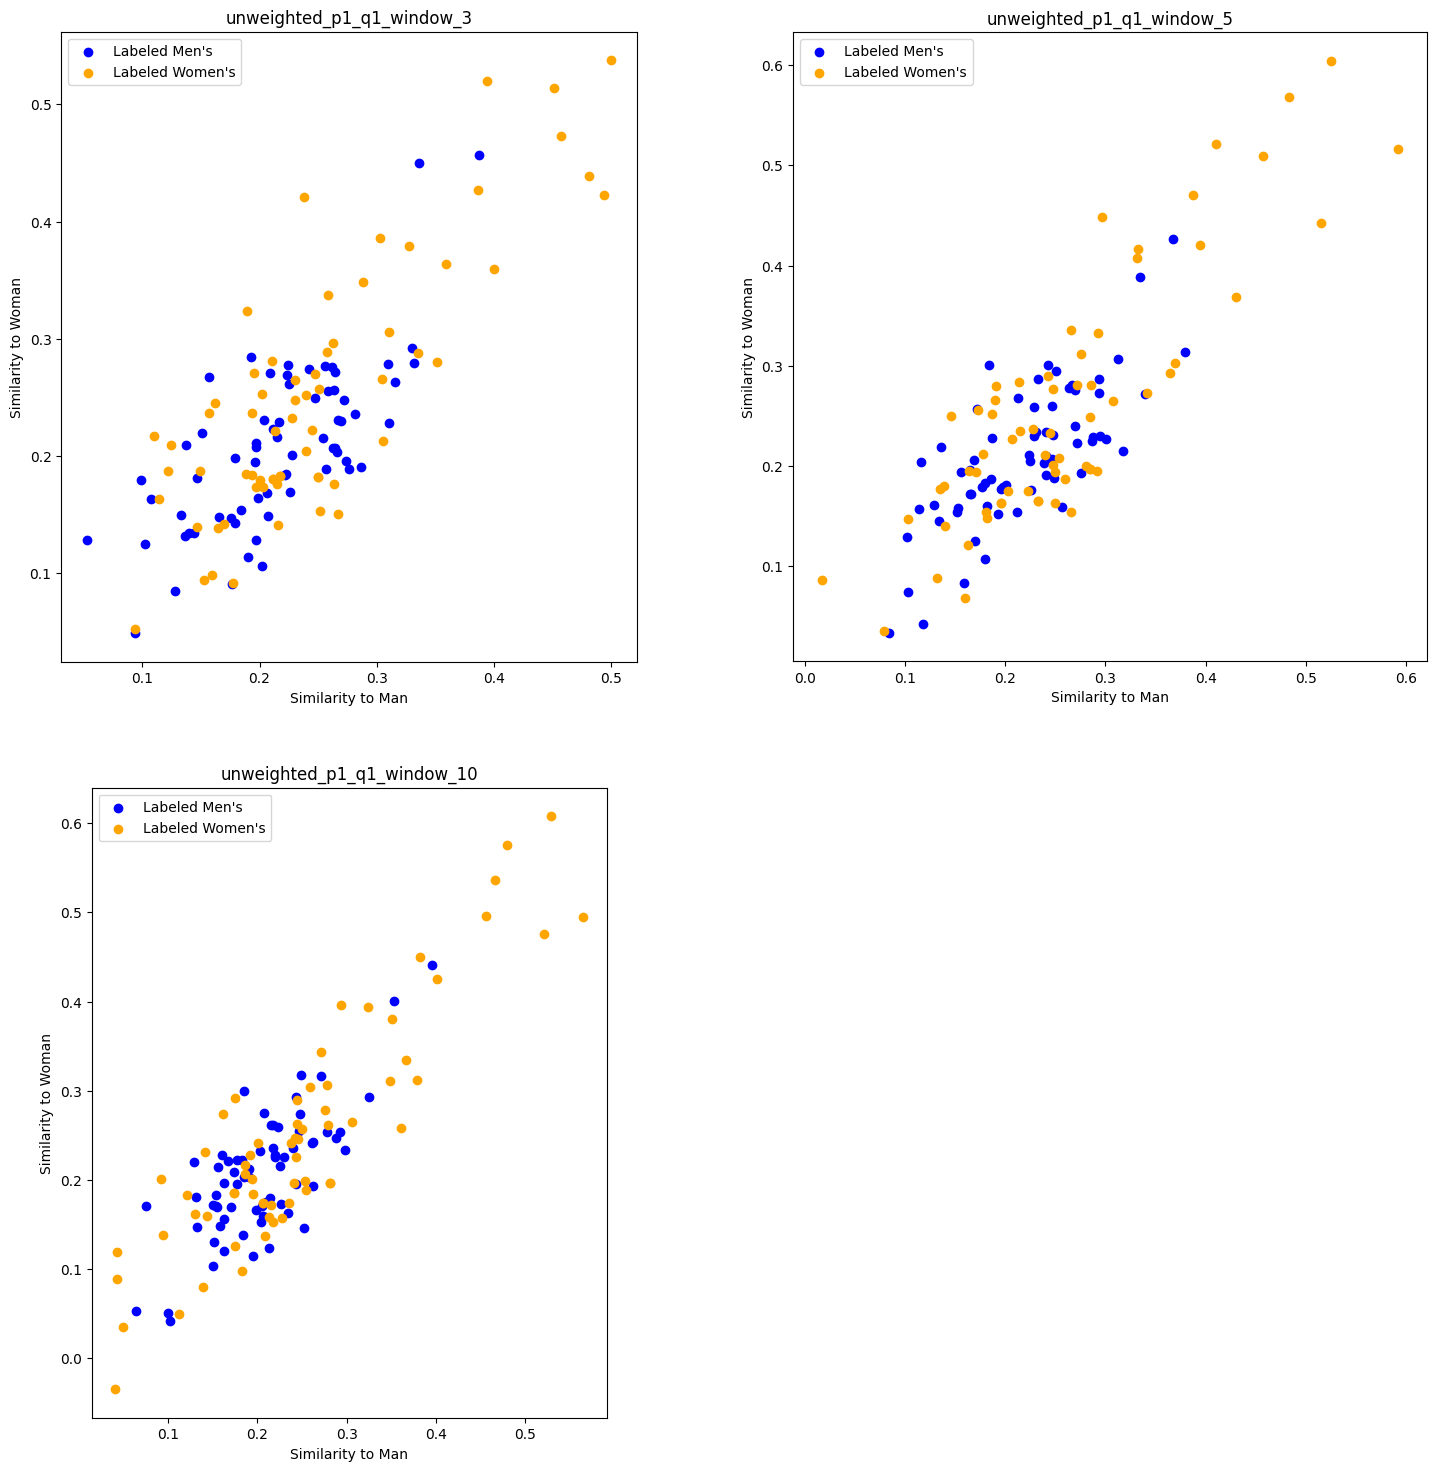

In [108]:
display_and_save_bias_plots(model_list=unweighted_graph_models, label='unweighted', p=1, q=1)

['unweighted_p1_q2_window_3', 'unweighted_p1_q2_window_5', 'unweighted_p1_q2_window_10']


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 271.86it/s]

plots saved to ../figures/bias_plots_unweighted__p1_q2.png


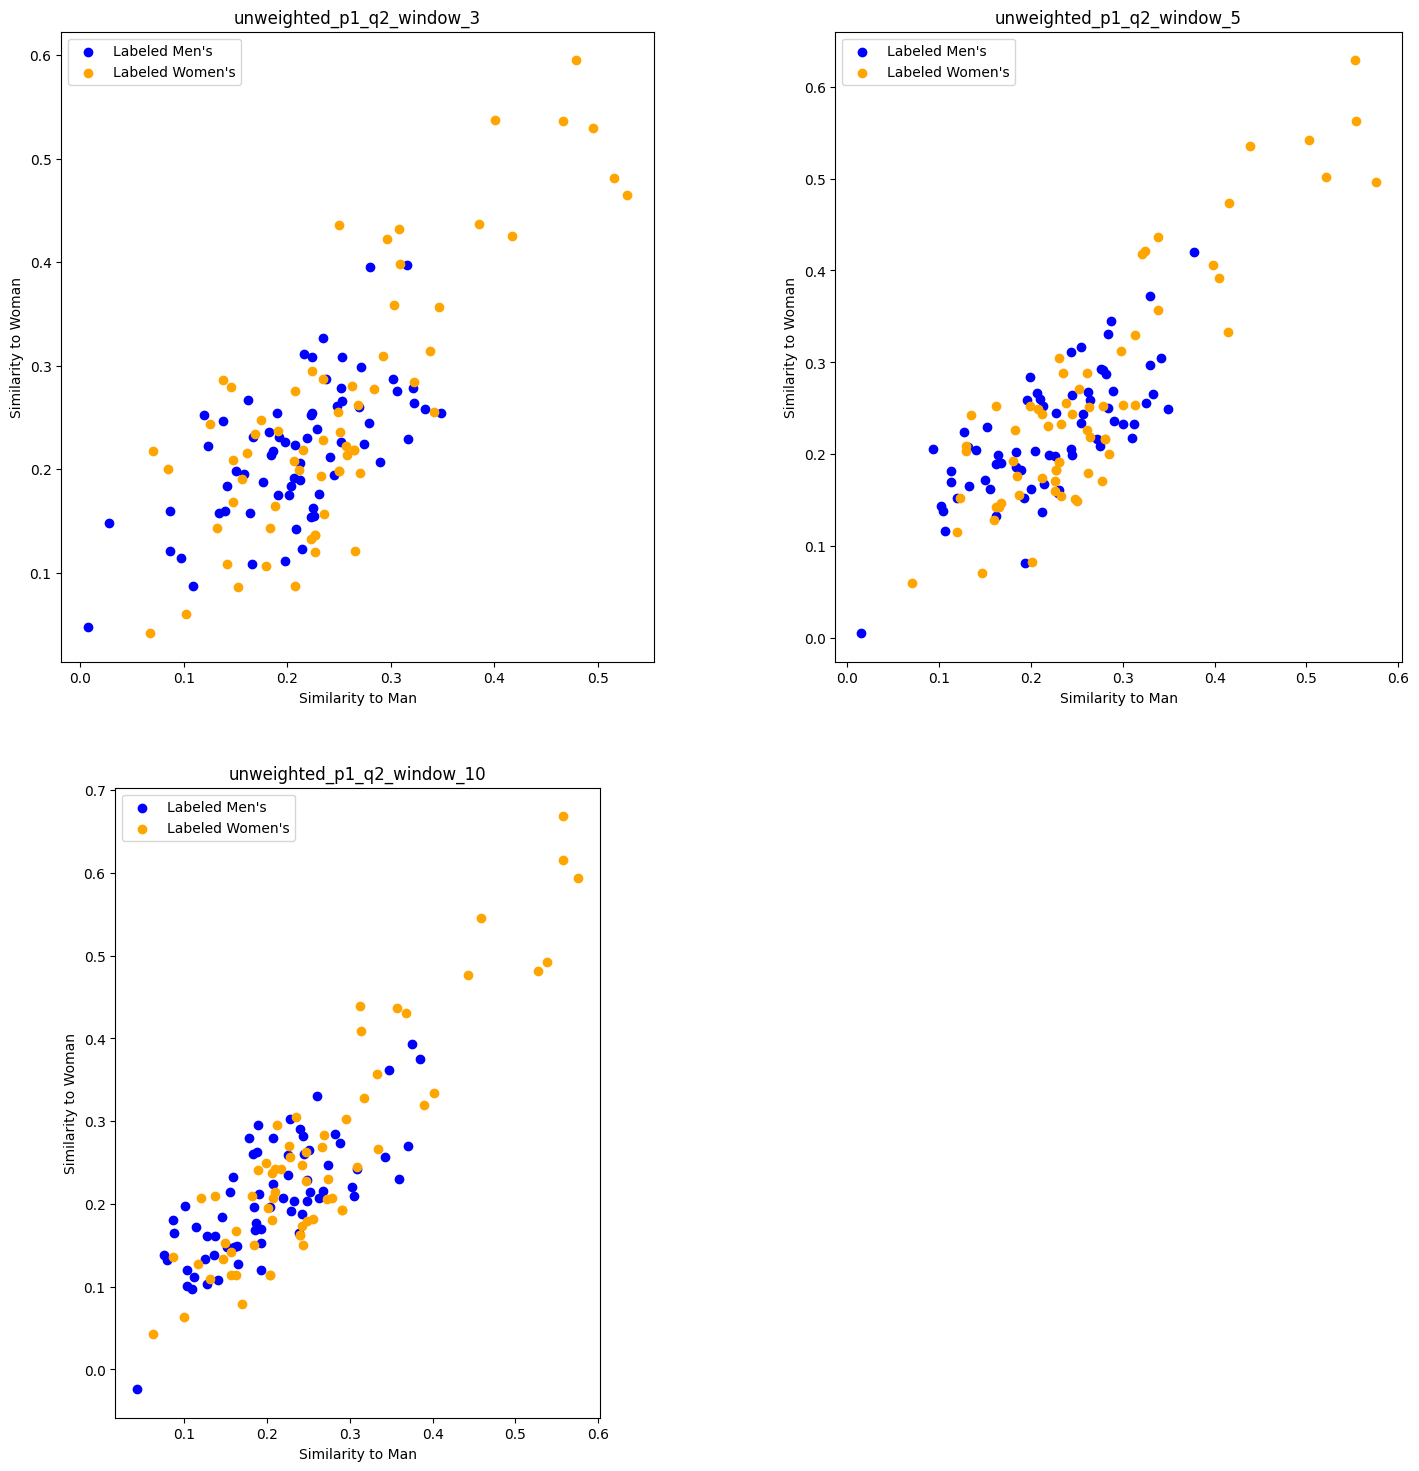

In [109]:
display_and_save_bias_plots(model_list=unweighted_graph_models, label='unweighted', p=1, q=2)

##### Weighted Graph Embeddings

['weighted_p1_q0.25_window_3', 'weighted_p1_q0.25_window_5', 'weighted_p1_q0.25_window_10']


100%|██████████| 3/3 [00:00<00:00, 261.82it/s]

plots saved to ../figures/bias_plots_weighted__p1_q0.25.png


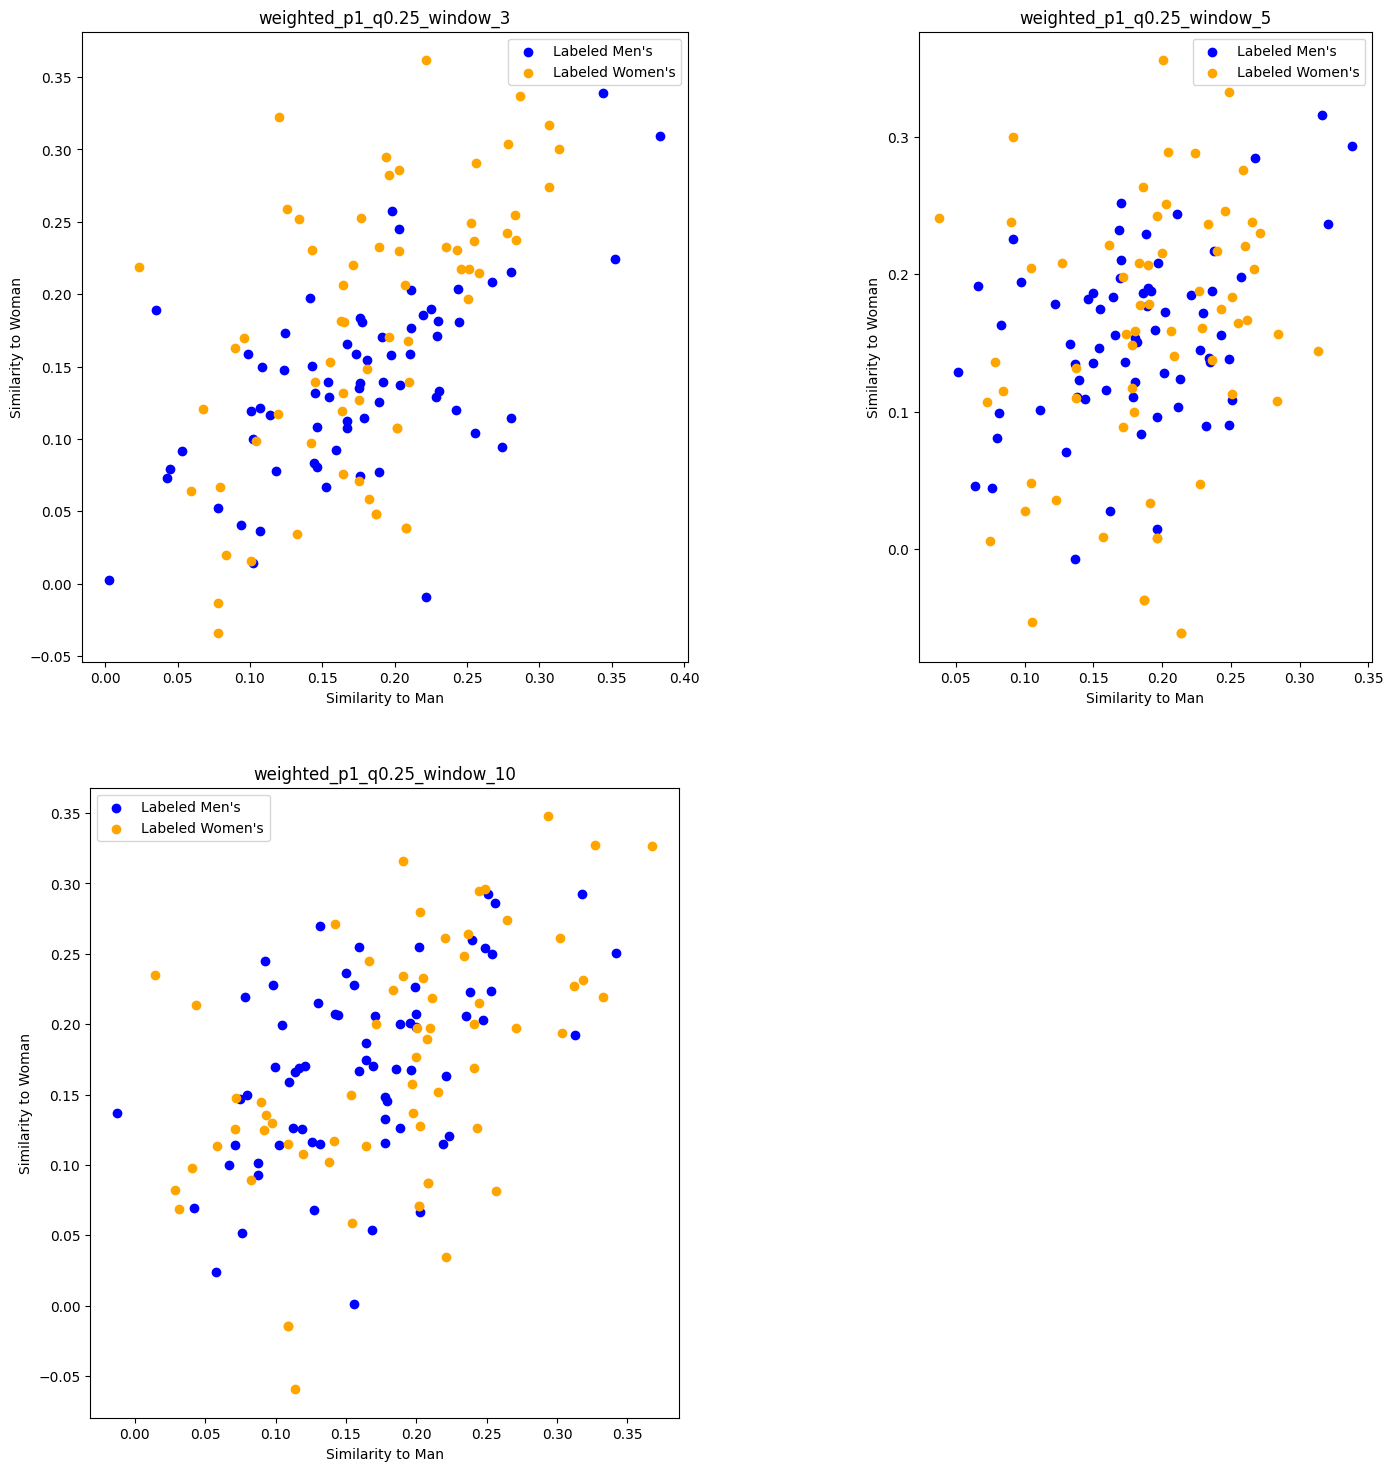

In [110]:
display_and_save_bias_plots(model_list=weighted_graph_models, label='weighted', p=1, q=0.25)

['weighted_p1_q0.5_window_3', 'weighted_p1_q0.5_window_5', 'weighted_p1_q0.5_window_10']


100%|██████████| 3/3 [00:00<00:00, 303.33it/s]

plots saved to ../figures/bias_plots_weighted__p1_q0.5.png

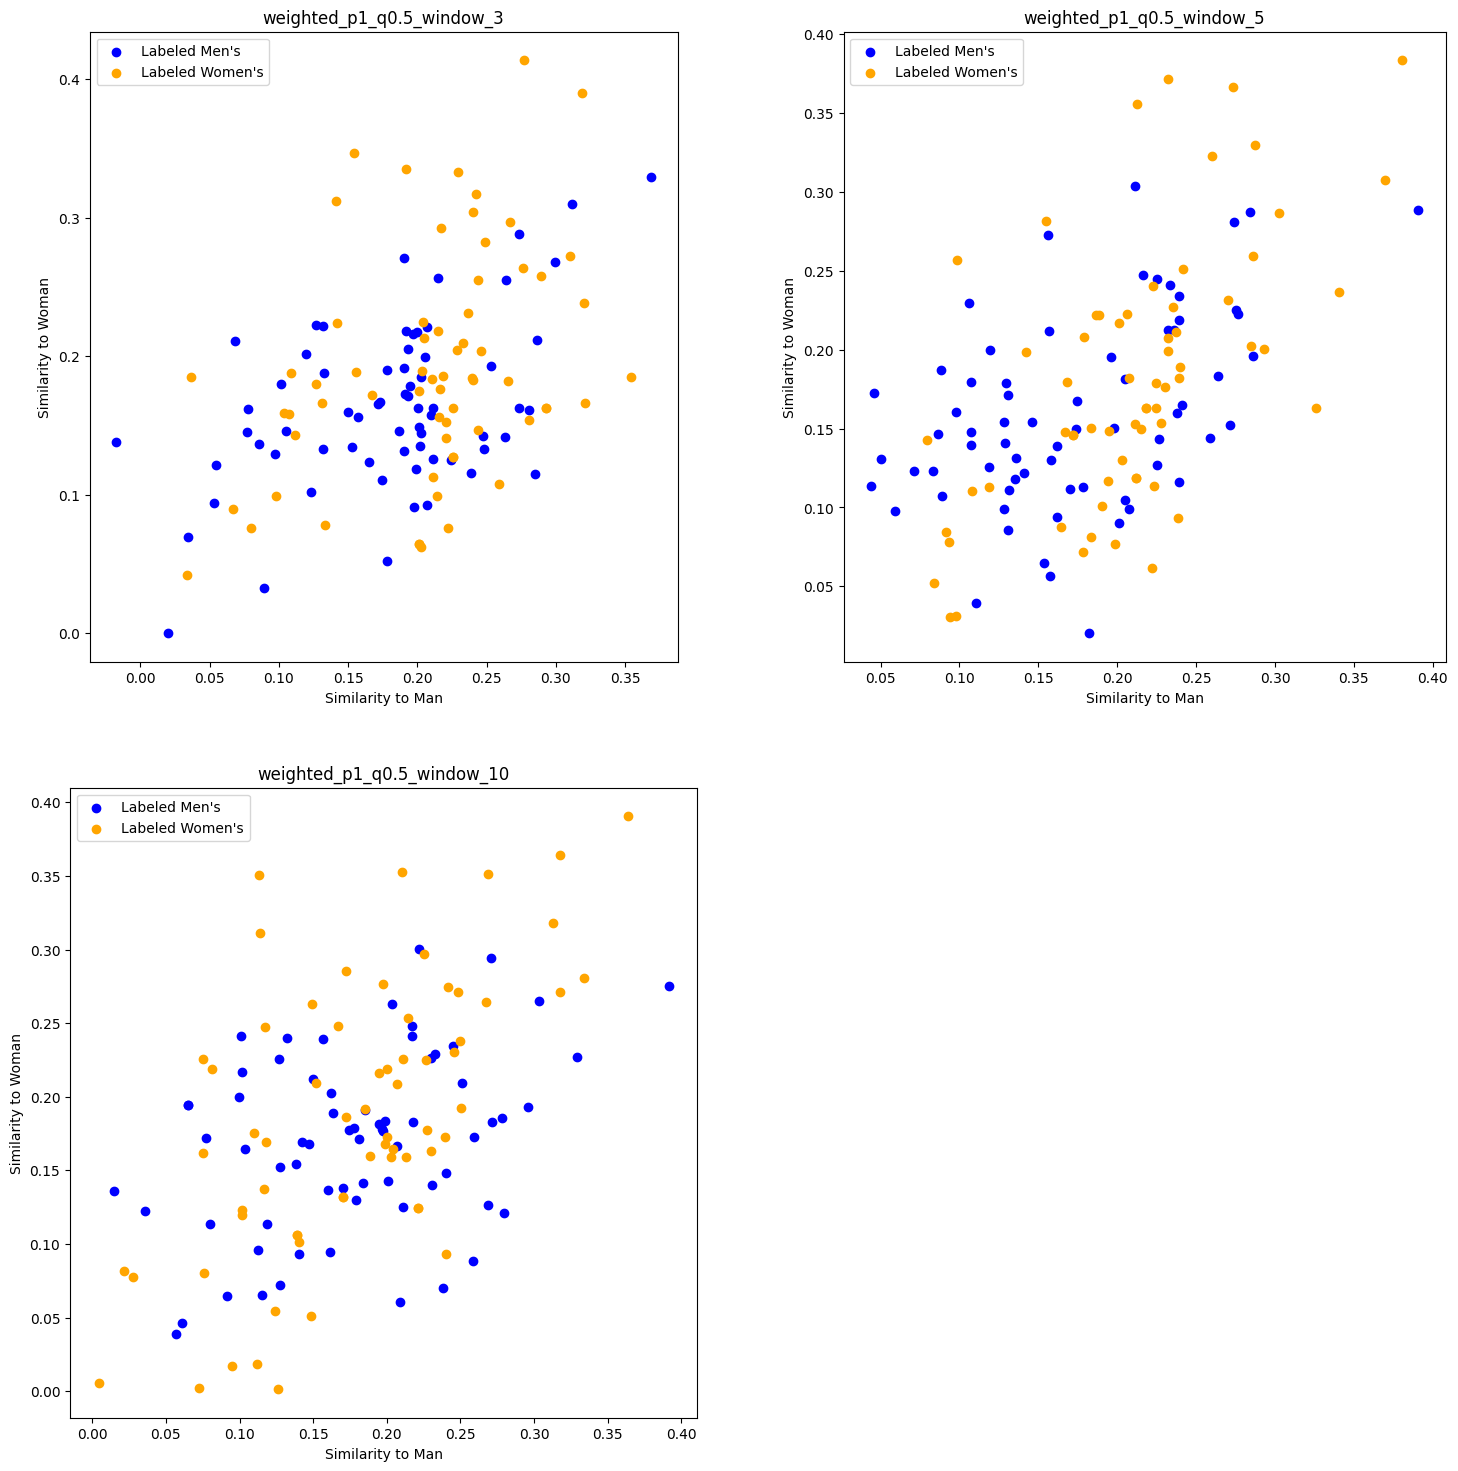

In [111]:
display_and_save_bias_plots(model_list=weighted_graph_models, label='weighted', p=1, q=0.5)

['weighted_p1_q1_window_3', 'weighted_p1_q1_window_5', 'weighted_p1_q1_window_10']


100%|██████████| 3/3 [00:00<00:00, 258.20it/s]

plots saved to ../figures/bias_plots_weighted__p1_q1.png


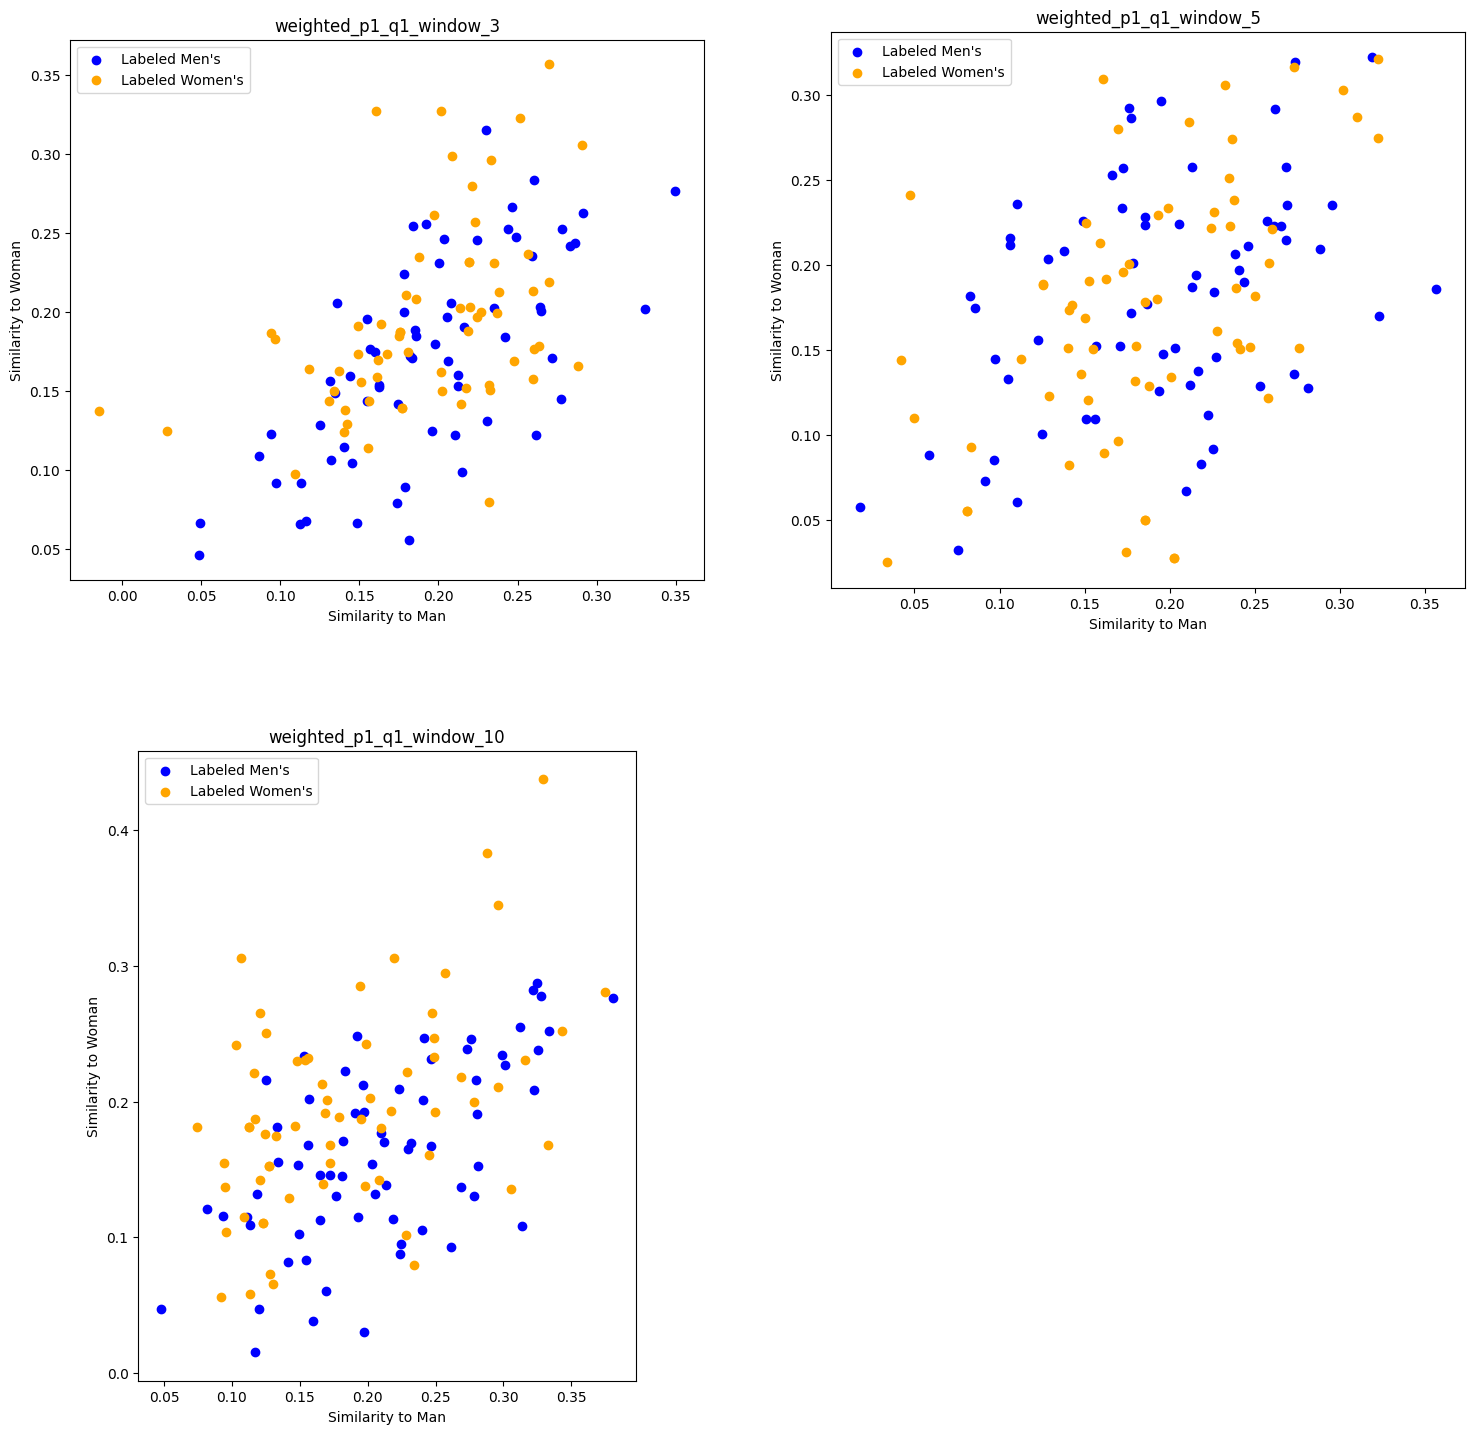

In [112]:
display_and_save_bias_plots(model_list=weighted_graph_models, label='weighted', p=1, q=1)

['weighted_p1_q2_window_3', 'weighted_p1_q2_window_5', 'weighted_p1_q2_window_10']


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 272.78it/s]

plots saved to ../figures/bias_plots_weighted__p1_q2.png


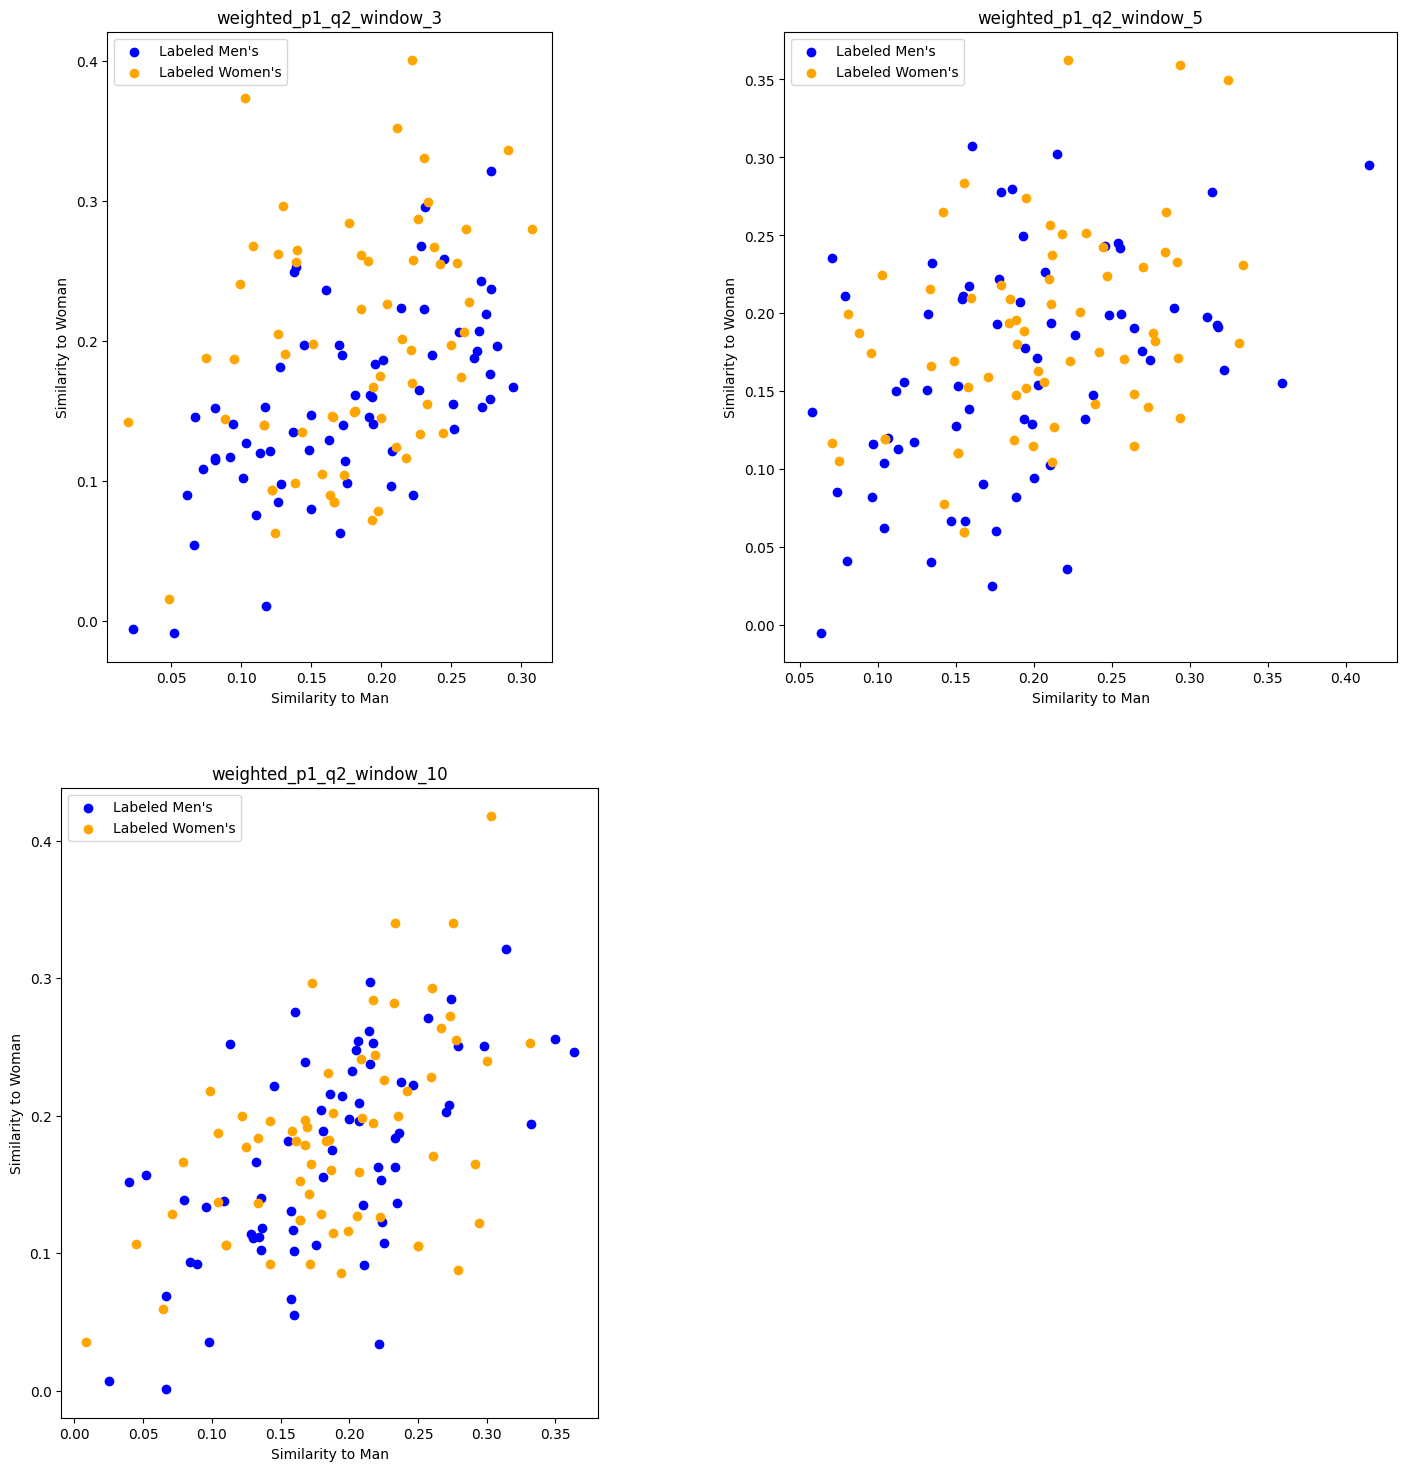

In [113]:
display_and_save_bias_plots(model_list=weighted_graph_models, label='weighted', p=1, q=2)